In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [103]:
data= pd.read_csv(r"C:\Users\USER\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [104]:
print("Shape:", data.shape)

Shape: (7043, 21)


In [105]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [106]:
from sklearn.preprocessing import LabelEncoder
obj1=LabelEncoder()
obj2=LabelEncoder()
obj3=LabelEncoder()
obj4=LabelEncoder()   
obj5=LabelEncoder()
obj6=LabelEncoder()
obj7=LabelEncoder()
obj8=LabelEncoder()
obj9=LabelEncoder()
obj10=LabelEncoder()
obj11=LabelEncoder()
obj12=LabelEncoder()
obj13=LabelEncoder()
obj14=LabelEncoder()
obj15=LabelEncoder()
obj16=LabelEncoder()
obj17=LabelEncoder()
obj18=LabelEncoder()
data['customerID']=obj1.fit_transform(data['customerID'])
data['gender']=obj2.fit_transform(data['gender'])
data['Partner']=obj3.fit_transform(data['Partner'])
data['Dependents']=obj4.fit_transform(data['Dependents'])
data['PhoneService']=obj5.fit_transform(data['PhoneService'])
data['MultipleLines']=obj6.fit_transform(data['MultipleLines'])
data['InternetService']=obj7.fit_transform(data['InternetService'])
data['OnlineSecurity']=obj8.fit_transform(data['OnlineSecurity'])
data['OnlineBackup']=obj9.fit_transform(data['OnlineBackup'])
data['DeviceProtection']=obj10.fit_transform(data['DeviceProtection'])
data['TechSupport']=obj11.fit_transform(data['TechSupport'])
data['StreamingTV']=obj12.fit_transform(data['StreamingTV'])
data['StreamingMovies']=obj13.fit_transform(data['StreamingMovies'])
data['Contract']=obj14.fit_transform(data['Contract'])
data['PaperlessBilling']=obj15.fit_transform(data['PaperlessBilling'])
data['PaymentMethod']=obj16.fit_transform(data['PaymentMethod'])
data['Churn']=obj17.fit_transform(data['Churn'])
data['TotalCharges']=obj18.fit_transform(data['TotalCharges'])


In [107]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1


In [108]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,4853,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,3367,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,5934,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1
7042,2226,1,0,0,0,66,1,0,1,2,...,2,2,2,2,2,1,0,105.65,5407,0


In [109]:
print("Shape:", data.shape)

Shape: (7043, 21)


In [110]:
data.describe()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,3521.000000,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.940508,0.872923,0.790004,...,0.904444,0.797104,0.985376,0.992475,0.690473,0.592219,1.574329,64.761692,3257.794122,0.265370
std,2033.283305,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.948554,0.737796,0.859848,...,0.879949,0.861551,0.885002,0.885091,0.833755,0.491457,1.068104,30.090047,1888.693496,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000
25%,1760.500000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,35.500000,1609.000000,0.000000
50%,3521.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,70.350000,3249.000000,0.000000
75%,5281.500000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,2.000000,1.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.850000,4901.500000,1.000000
max,7042.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,6530.000000,1.000000


In [111]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [112]:
data = data.drop_duplicates()

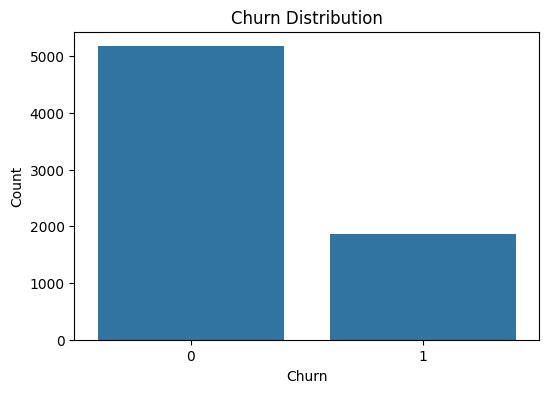

In [113]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

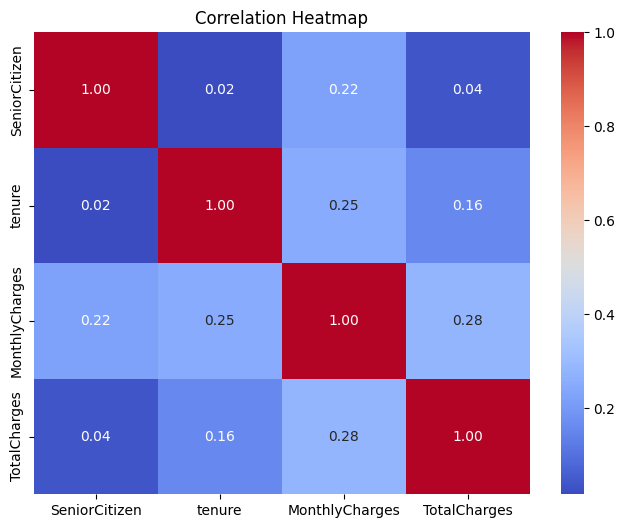

In [114]:
##  correlation heatmap
numeric_df = data[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
]
correlation = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

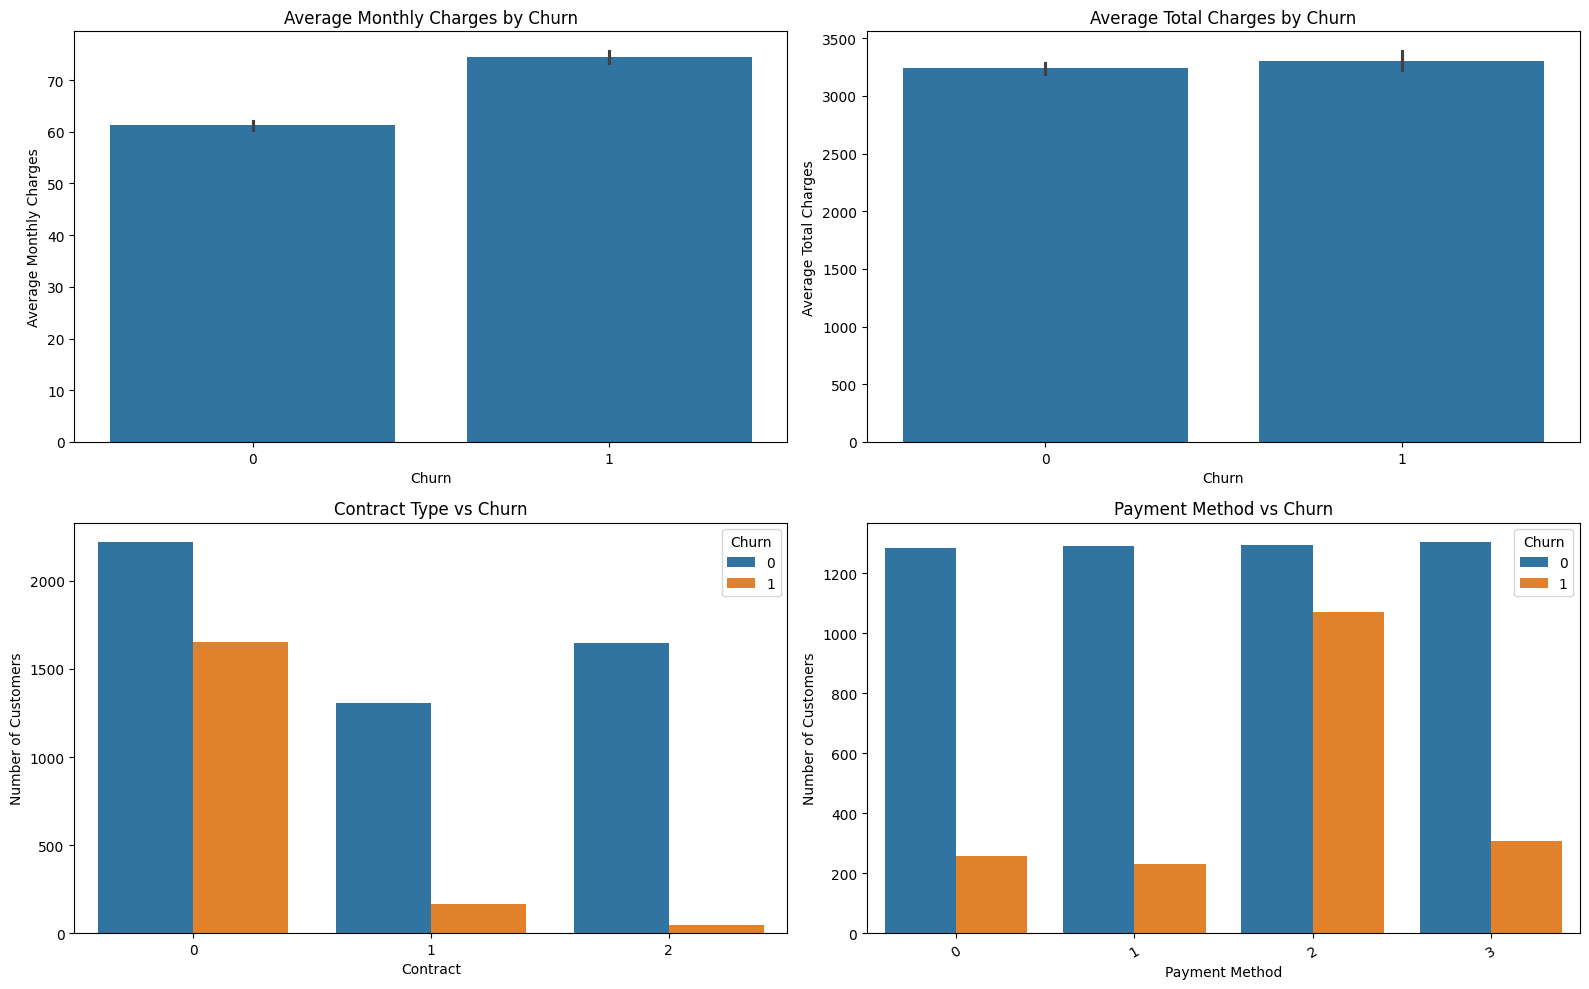

In [115]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly Charges
sns.barplot(
    data=data,
    x="Churn",
    y="MonthlyCharges",
    estimator="mean",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Average Monthly Charges by Churn")
axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Average Monthly Charges")


# Total Charges
sns.barplot(
    data=data,
    x="Churn",
    y="TotalCharges",
    estimator="mean",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Average Total Charges by Churn")
axes[0, 1].set_xlabel("Churn")
axes[0, 1].set_ylabel("Average Total Charges")


# Contract
sns.countplot(
    data=data,
    x="Contract",
    hue="Churn",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Contract Type vs Churn")
axes[1, 0].set_xlabel("Contract")
axes[1, 0].set_ylabel("Number of Customers")


# Payment Method
sns.countplot(
    data=data,
    x="PaymentMethod",
    hue="Churn",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Payment Method vs Churn")
axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].set_ylabel("Number of Customers")

axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()

plt.show()

In [148]:
# plt.figure(figsize=(10,5))
# sns.barplot(
#     x="Model",
#     y="Accuracy",
#     data=results
# )
# plt.title("Classification Model Accuracy Comparison")
# plt.xlabel("Models")
# plt.ylabel("Accuracy")

# plt.xticks(rotation=30)

# plt.show()

In [118]:
data.dtypes

customerID            int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges          int64
Churn                 int64
dtype: object

In [119]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

In [120]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [122]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print

Training data: (5634, 20)
Testing data: (1409, 20)


<function print>

In [123]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [124]:
#### logistic regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [125]:
log_accuracy = accuracy_score(y_test, y_pred_log)*100
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 79.13413768630234


In [126]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [127]:
##KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

In [128]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)*100
print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 74.73385379701917


In [129]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1035
           1       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



In [130]:
##Decision tree classifier
dt_model = DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [131]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)*100
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 70.40454222853087


In [132]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1035
           1       0.45      0.48      0.46       374

    accuracy                           0.70      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.70      0.71      1409



In [133]:
##Random forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [134]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)*100
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 79.347054648687


In [135]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [136]:
## svm
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

In [137]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)*100
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 79.13413768630234


In [138]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1035
           1       0.65      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [139]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    
    "Accuracy": [
        log_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,79.134138
1,KNN,74.733854
2,Decision Tree,70.404542
3,Random Forest,79.347055
4,SVM,79.134138


In [140]:
models = {
    "Logistic Regression": (
        log_model,
        X_train_scaled,
        X_test_scaled
    ),
    
    "KNN": (
        knn_model,
        X_train_scaled,
        X_test_scaled
    ),
    
    "Decision Tree": (
        dt_model,
        X_train,
        X_test
    ),
    
    "Random Forest": (
        rf_model,
        X_train,
        X_test
    ),
    
    "SVM": (
        svm_model,
        X_train_scaled,
        X_test_scaled
    )
}


train_scores = []
test_scores = []

model_names = []

for name, (model, train_data, test_data) in models.items():

    train_pred = model.predict(train_data)
    test_pred = model.predict(test_data)

    train_score = accuracy_score(y_train, train_pred)
    test_score = accuracy_score(y_test, test_pred)

    model_names.append(name)
    train_scores.append(train_score)
    test_scores.append(test_score)

In [141]:
## classification table
score_comparison = pd.DataFrame({
    "Model": model_names,
    "Training Accuracy":train_scores,
    "Testing Accuracy": test_scores
})

score_comparison

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.806532,0.791341
1,KNN,0.835286,0.747339
2,Decision Tree,1.000000,0.704045
3,Random Forest,1.000000,0.793471
4,SVM,0.832446,0.791341


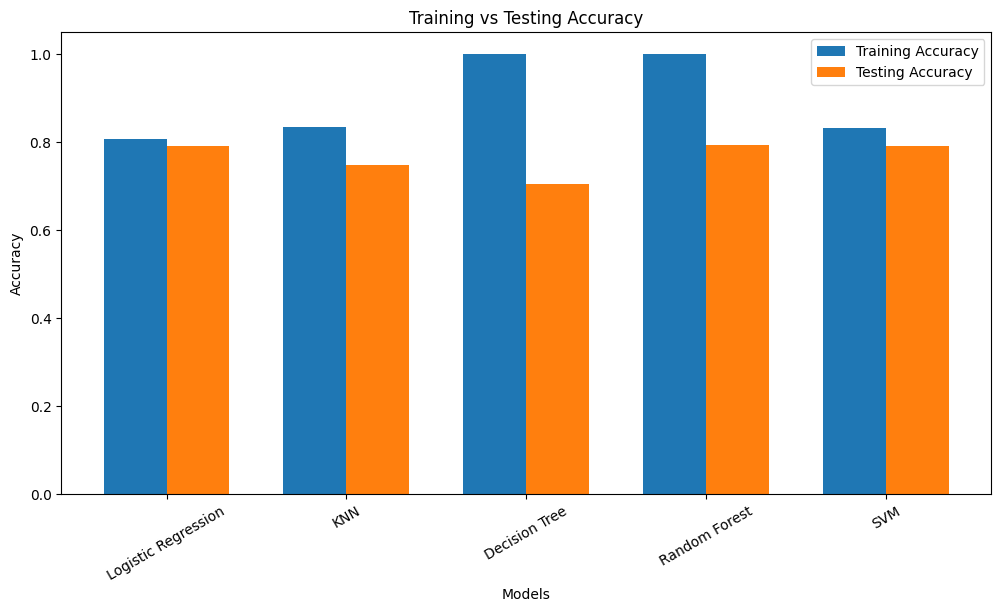

In [142]:
###training vs testing accuracy bar chart
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    train_scores,
    width,
    label="Training Accuracy"
)

plt.bar(
    x + width/2,
    test_scores,
    width,
    label="Testing Accuracy"
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")

plt.xticks(x, model_names, rotation=30)

plt.legend()

plt.show()

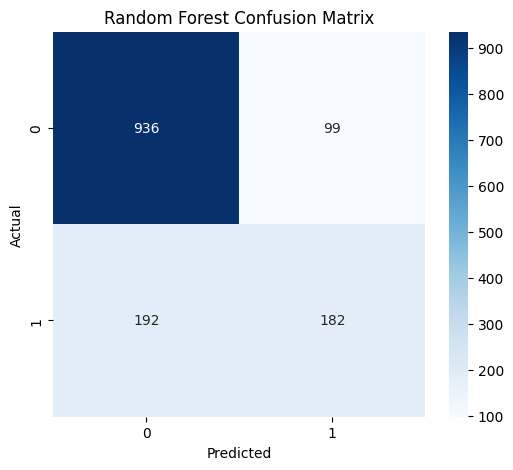

In [143]:
## confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [144]:
## Precision , Recall, F1 score
model_predictions = {
    "Logistic Regression": y_pred_log,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}
comparison = []

for name, prediction in model_predictions.items():

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction)*100,
        "Precision": precision_score(y_test, prediction)*100,
        "Recall": recall_score(y_test, prediction)*100,
        "F1 Score": f1_score(y_test, prediction)*100
    })
metrics_df = pd.DataFrame(comparison)
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,79.134138,63.071895,51.604278,56.764706
1,KNN,74.733854,52.542373,49.732620,51.098901
2,Decision Tree,70.404542,44.611529,47.593583,46.054334
3,Random Forest,79.347055,64.768683,48.663102,55.572519
4,SVM,79.134138,64.598540,47.326203,54.629630


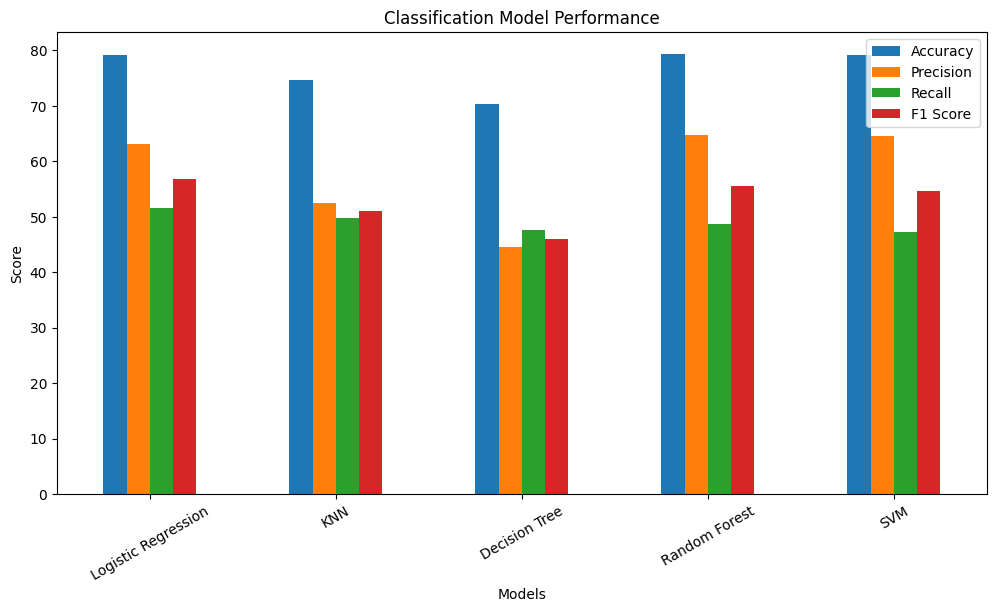

In [145]:
metrics_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Classification Model Performance")
plt.ylabel("Score")
plt.xlabel("Models")

plt.xticks(rotation=30)

plt.legend()

plt.show()

In [146]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]
print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])

Best Model: Random Forest
Accuracy: 79.347054648687


In [147]:
print("Random Forest Classification Report")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

